# Simulation-Based Inference for Gravitational-Wave Parameters

This notebook applies **simulation-based inference (SBI)** to a simplified gravitational-wave frequency-domain waveform. The goal is to learn the posterior distribution of waveform parameters directly from simulated observations using **Neural Posterior Estimation (NPE)**.

The workflow follows the same structure as the linear-regression notebook:

1. define a physics-based simulator,
2. specify parameter priors,
3. generate simulations,
4. train a neural posterior estimator, and
5. infer parameters for an observed waveform.

The waveform is intentionally simplified so that the focus remains on the SBI workflow rather than on a full gravitational-wave likelihood analysis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from sbi import analysis
from sbi.inference import NPE
from sbi.utils import BoxUniform
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

## Simplified gravitational-wave model

The full notebook explored the TaylorF2 frequency-domain waveform. Here, we use the simplified form

$$
h(f) = A f^{-7/6} e^{2\pi i f t_c},
$$

where $A$ controls the amplitude and $t_c$ controls the phase evolution. The simulator returns the real part of the waveform over a frequency grid.

To improve numerical conditioning, the inference parameter is $\log_{10}(A)$ rather than $A$ itself.

In [4]:
def simulator(theta):
    """Generate simplified frequency-domain gravitational-wave signals.

    theta[:, 0] = log10(amplitude)
    theta[:, 1] = coalescence time
    """
    f_lower = 20.0
    f_final = 40.0
    delta_f = 1 / 16

    n_freq = int(np.round((f_final - f_lower) / delta_f + 1, 0))

    f_array = torch.linspace(
        f_lower,
        f_final,
        n_freq,
        dtype=theta.dtype,
        device=theta.device
    )

    log_amplitude = theta[:, 0]
    tc = theta[:, 1]
    amplitude = 10 ** log_amplitude

    phase = 2 * torch.pi * f_array[None, :] * tc[:, None]

    waveform = (
        amplitude[:, None]
        * f_array[None, :] ** (-7 / 6)
        * torch.cos(phase)
    )

    return waveform.float()

def frequency_grid():
    return np.linspace(20.0, 40.0, int(np.round((40.0 - 20.0) / (1 / 16) + 1, 0)))



Before training the inference model, we visualize several simulated waveforms to check that changes in the parameters produce distinct signal structures.

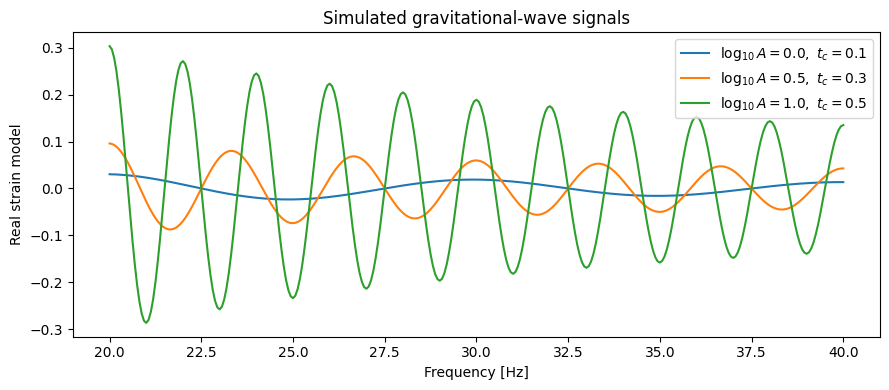

In [5]:
f_array = frequency_grid()
theta_demo = torch.tensor([
    [0.0, 0.1],
    [0.5, 0.3],
    [1.0, 0.5],
])

h_demo = simulator(theta_demo)

plt.figure(figsize=(9, 4))
for i in range(len(theta_demo)):
    plt.plot(f_array, h_demo[i], label=fr"$\log_{{10}}A={theta_demo[i,0]:.1f},\ t_c={theta_demo[i,1]:.1f}$")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Real strain model")
plt.title("Simulated gravitational-wave signals")
plt.legend()
plt.tight_layout()
plt.show()

### Prior distribution


In [6]:
log_amplitude_lower = 0.0
log_amplitude_upper = 1.0
tc_lower = 0.1
tc_upper = 0.5

prior = BoxUniform(
    low=torch.tensor([log_amplitude_lower, tc_lower]),
    high=torch.tensor([log_amplitude_upper, tc_upper]),
)

prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulator = process_simulator(simulator, prior, prior_returns_numpy)
check_sbi_inputs(simulator, prior)

print(f"Number of inferred parameters: {num_parameters}")

Number of inferred parameters: 2


We draw parameter values from the prior, simulate the corresponding waveforms, and train a conditional density estimator with **Neural Posterior Estimation (NPE)**.

The original analysis used **2,000 simulations** for training. The learned posterior can then be conditioned on a new waveform to infer its parameters.

In [7]:
num_simulations = 2000

theta_train = prior.sample((num_simulations,))
h_train = simulator(theta_train)

inference = NPE(
    prior=prior,
    density_estimator="zuko_maf",
)

inference = inference.append_simulations(theta_train, h_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 139 epochs.

### Posterior inference

In [8]:
theta_true = prior.sample((1,))
h_obs = simulator(theta_true)

num_posterior_samples = 10000
samples = posterior.sample((num_posterior_samples,), x=h_obs)

print("True parameters:", theta_true.numpy())

  0%|          | 0/10000 [00:00<?, ?it/s]

True parameters: [[0.369227   0.46796775]]


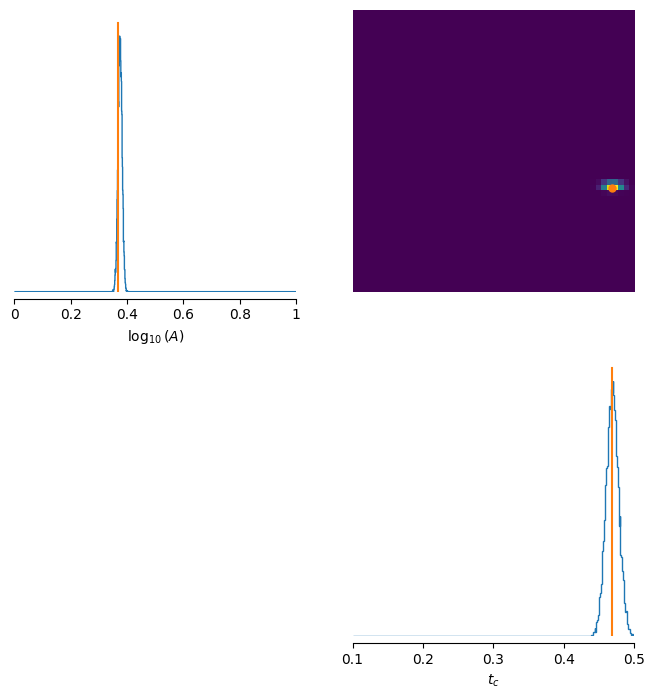

In [9]:
analysis.pairplot(
    samples,
    limits=[
        [log_amplitude_lower, log_amplitude_upper],
        [tc_lower, tc_upper],
    ],
    figsize=(8, 8),
    labels=[r"$\log_{10}(A)$", r"$t_c$"],
    points=theta_true,
)
plt.show()

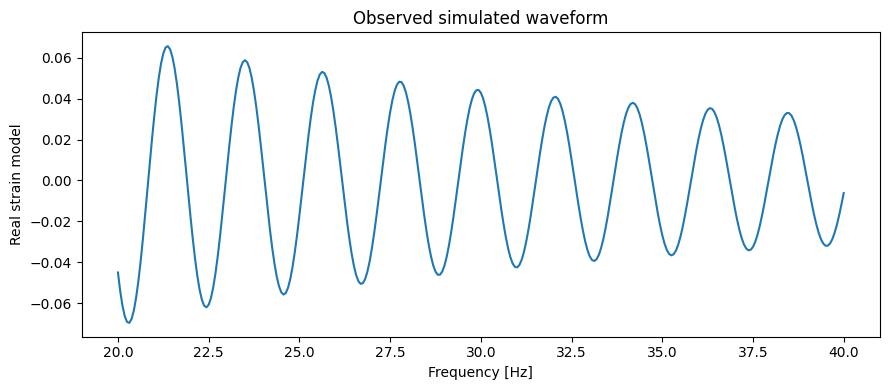

In [10]:
plt.figure(figsize=(9, 4))
plt.plot(f_array, h_obs[0].numpy())
plt.xlabel("Frequency [Hz]")
plt.ylabel("Real strain model")
plt.title("Observed simulated waveform")
plt.tight_layout()
plt.show()

## Summary

- Built a differentiable-style simulation workflow for a simplified gravitational-wave frequency-domain signal.
- Used log-amplitude and coalescence-time parameters with a uniform prior.
- Trained an NPE model with a masked autoregressive flow (`zuko_maf`) on **2,000 simulated waveforms**.
- Drew **10,000 posterior samples** conditioned on a new simulated observation.
- Visualized the resulting posterior to assess parameter recovery and uncertainty.

The linear-regression notebook provides the controlled validation case for the same SBI methodology, while this notebook demonstrates its application to a physics-based gravitational-wave simulator.